# Лабораторная работа № 4
## «Численные методы решения задачи Коши»

**Вариант:** 11  
**Выполнил:** Стаселько Илья

### 1. Постановка задачи
На равномерной сетке с помощью неявного метода трапеций и явного метода Рунге-Кутты (заданного таблицей Бутчера) мне необходимо найти численное решение задачи Коши с шагами $h = 0.1$ и $h/2 = 0.05$. Обозначим эти решения как $y^h$ и $y^{h/2}$ соответственно.

**Исходная задача Коши:**
$$ u' = -\frac{u}{x}\ln\left(\frac{u}{x}\right), \quad x \in [1, 2] $$
$$ u(1) = 1 $$

**Точное решение:**
$$ u(x) = x e^{\frac{1-x}{x}} $$

Для неявного метода трапеций решение нелинейного уравнения на каждом шаге я буду выполнять с помощью метода Ньютона. 

**Необходимо:**
1. Сравнить найденное численное решение $y^{h/2}$ с точным решением $u(x)$, вычислив максимальную погрешность: $\max_{i} |u_i - y_i^{h/2}|$.

2. Вычислить оценку погрешности по правилу Рунге:
$$ R \approx \frac{\max_{i} |y_i^h - y_{2i}^{h/2}|}{2^p - 1} $$
где $N = (b-a)/h$, а $p$ — теоретический порядок точности метода.

3. В одной системе координат построить непрерывный график точного решения $u(x)$ и точечный график полученного численного решения $y^{h/2}$.

---

### 2. Применяемые численные методы и теория

Задачу Коши мы рассматриваем в виде:
$$ u'(x) = f(x, u(x)), \quad x_0 \leqslant x \leqslant X $$
В моем случае $f(x, u) = -\frac{u}{x}\ln\left(\frac{u}{x}\right)$.

#### 2.1. Неявный метод трапеций
Неявный метод трапеций выводится из интегрирования исходного дифференциального уравнения с применением квадратурной формулы трапеций. Метод имеет 2-й порядок аппроксимации ($p=2$) и записывается в виде:
$$ y_{j+1} = y_j + \frac{h}{2} \Big( f(x_j, y_j) + f(x_{j+1}, y_{j+1}) \Big) $$

Поскольку значение $y_{j+1}$ входит как в левую, так и в правую часть нелинейным образом, для его нахождения на каждом шаге я применяю **метод Ньютона**.

Перепишем уравнение в виде поиска корня функции $F(Y) = 0$, где $Y = y_{j+1}$:
$$ F(Y) = Y - y_j - \frac{h}{2} \Big( f(x_j, y_j) + f(x_{j+1}, Y) \Big) = 0 $$

Итерационный процесс Ньютона выглядит так:
$$ Y^{(k+1)} = Y^{(k)} - \frac{F(Y^{(k)})}{F'(Y^{(k)})} $$

Вычислю производную $F'(Y)$. Для этого мне нужна частная производная правой части $f_u'(x, u)$:
$$ f_u'(x, u) = \frac{\partial}{\partial u} \left( -\frac{u}{x}\ln\left(\frac{u}{x}\right) \right) = -\frac{1}{x}\ln\left(\frac{u}{x}\right) - \frac{u}{x} \cdot \frac{x}{u} \cdot \frac{1}{x} = -\frac{1}{x} \left( \ln\left(\frac{u}{x}\right) + 1 \right) $$

Тогда производная функции $F(Y)$:
$$ F'(Y) = 1 - \frac{h}{2} f_u'(x_{j+1}, Y) $$

В качестве начального приближения $Y^{(0)}$ логично брать значение, полученное явным методом Эйлера: $Y^{(0)} = y_j + h f(x_j, y_j)$.

#### 2.2. Явный метод Рунге-Кутта
Семейство методов Рунге-Кутта задается через параметры $\alpha, \beta, A$:
$$ y_{j+1} = y_j + \sum_{i=0}^q A_i \varphi_i $$
$$ \varphi_i = h f\left(x_j + \alpha_i h, y_j + \sum_{m=0}^{i-1} \beta_{im} \varphi_m\right) $$

$$ \varphi_0 = h f(x_j, y_j) $$
$$ \varphi_1 = h f(x_j + \alpha_1 h, y_j + \beta_{10} \varphi_0) $$
$$ \varphi_2 = h f(x_j + \alpha_2 h, y_j + \beta_{20} \varphi_0 + \beta_{21} \varphi_1) $$

### Общий вид таблицы Бутчера для явных методов Рунге-Кутта

В общем виде для $q$-этапного метода параметры $\alpha$ (узлы), $\beta$ (матрица коэффициентов) и $A$ (веса) записываются в виде таблицы Бутчера следующим образом:

$$
\begin{array}{c|ccccc}
0 & & & & & \\
\alpha_1 & \beta_{10} & & & & \\
\alpha_2 & \beta_{20} & \beta_{21} & & & \\
\vdots & \vdots & \vdots & \ddots & & \\
\alpha_q & \beta_{q0} & \beta_{q1} & \cdots & \beta_{q, q-1} & \\
\hline
& A_0 & A_1 & A_2 & \cdots & A_q
\end{array}
$$

* **Левый столбец ($\alpha$)** определяет, на какую долю шага $h$ мы сдвигаемся по оси $x$.
* **Внутренняя матрица ($\beta$)** определяет, с какими весами берутся предыдущие наклоны $\varphi$ для вычисления текущего. У явных методов эта матрица строго нижнетреугольная (зависит только от уже вычисленных значений).
* **Нижняя строка ($A$)** — это весовые коэффициенты, с которыми все найденные наклоны $\varphi_i$ суммируются для получения итогового значения $y_{j+1}$.

В моем варианте задана таблица Бутчера:
$$ \begin{array}{c|ccc} 0 & & & \\ 2/3 & 2/3 & & \\ 2/3 & -1/3 & 1 & \\ \hline & 1/4 & 2/4 & 1/4 \end{array} $$

Из нее я выделяю коэффициенты для 3-этапного метода ($q=2$). Это метод 3-го порядка точности ($p=3$):
* $A_0 = 1/4, \quad A_1 = 2/4, \quad A_2 = 1/4$
* $\alpha_1 = 2/3, \quad \beta_{10} = 2/3$
* $\alpha_2 = 2/3, \quad \beta_{20} = -1/3, \quad \beta_{21} = 1$

Соответственно, формулы для вычисления $\varphi$ примут вид:
$$ \varphi_0 = h f(x_j, y_j) $$
$$ \varphi_1 = h f\left(x_j + \frac{2}{3}h, y_j + \frac{2}{3}\varphi_0\right) $$
$$ \varphi_2 = h f\left(x_j + \frac{2}{3}h, y_j - \frac{1}{3}\varphi_0 + \varphi_1\right) $$
$$ y_{j+1} = y_j + \frac{1}{4}\varphi_0 + \frac{2}{4}\varphi_1 + \frac{1}{4}\varphi_2 $$

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Исходные данные ---
a = 1.0
b = 2.0
u0 = 1.0

# Функция правой части ОДУ f(x, u)
def f(x, u):
    # Защита от логарифма отрицательного числа/нуля
    u_safe = np.maximum(u, 1e-15) 
    return -(u_safe / x) * np.log(u_safe / x)

# Производная f'_u(x, u) для метода Ньютона
def df_du(x, u):
    u_safe = np.maximum(u, 1e-15)
    return -(1.0 / x) * (np.log(u_safe / x) + 1.0)

# Точное решение u(x)
def exact_solution(x):
    return x * np.exp((1.0 - x) / x)

### 3. Программная реализация численных методов

In [6]:
# --- 1. Неявный метод трапеций (с методом Ньютона) ---
def implicit_trapezoidal(h, eps_newton=1e-9, max_iter=100):
    N = int(np.round((b - a) / h))
    x_arr = np.linspace(a, b, N + 1) # Узлов на 1 больше, чем отрезков разбиения
    y_arr = np.zeros(N + 1)
    y_arr[0] = u0
    
    for j in range(N): # j = 0, 1, ..., N-1
        x_j = x_arr[j] # Текущий икс
        y_j = y_arr[j] # Текущий игрек
        x_jp1 = x_arr[j+1] # Следующий икс
        
        # Начальное приближение Ньютона (явный метод Эйлера)
        Y_k = y_j + h * f(x_j, y_j)
        
        # Итерационный процесс Ньютона
        for _ in range(max_iter):
            # F(Y) = Y - y_j - h/2 * (f(x_j, y_j) + f(x_{j+1}, Y))
            F_Y = Y_k - y_j - (h / 2.0) * (f(x_j, y_j) + f(x_jp1, Y_k))
            
            # F'(Y) = 1 - h/2 * f'_u(x_{j+1}, Y)
            dF_Y = 1.0 - (h / 2.0) * df_du(x_jp1, Y_k)
            
            Y_next = Y_k - F_Y / dF_Y
            
            if abs(Y_next - Y_k) < eps_newton:
                Y_k = Y_next
                break
            Y_k = Y_next
            
        y_arr[j+1] = Y_k
        
    return x_arr, y_arr

# --- 2. Явный метод Рунге-Кутта (3-го порядка) ---
def runge_kutta_explicit(h):
    N = int(np.round((b - a) / h))
    x_arr = np.linspace(a, b, N + 1)
    y_arr = np.zeros(N + 1)
    y_arr[0] = u0
    
    for j in range(N):
        x_j = x_arr[j]
        y_j = y_arr[j]
        
        # Вычисление phi_i
        phi_0 = h * f(x_j, y_j)
        phi_1 = h * f(x_j + (2.0/3.0)*h, y_j + (2.0/3.0)*phi_0)
        phi_2 = h * f(x_j + (2.0/3.0)*h, y_j - (1.0/3.0)*phi_0 + phi_1)
        
        y_arr[j+1] = y_j + 0.25*phi_0 + 0.5*phi_1 + 0.25*phi_2
        
    return x_arr, y_arr

### 4. Результаты вычислительного эксперимента

Теперь я проведу вычисления для шагов $h = 0.1$ и $h/2 = 0.05$ для каждого из методов, оценю погрешности с помощью точного решения и по правилу Рунге.

In [9]:
h1 = 0.1
h2 = 0.05

# Вычисления для неявного метода трапеций (p = 2)
x_trap_h1, y_trap_h1 = implicit_trapezoidal(h1)
x_trap_h2, y_trap_h2 = implicit_trapezoidal(h2)

# Вычисления для явного метода Рунге-Кутты (p = 3)
x_rk_h1, y_rk_h1 = runge_kutta_explicit(h1)
x_rk_h2, y_rk_h2 = runge_kutta_explicit(h2)

# Точное решение на сетке h2 (более частой)
u_exact_h2 = exact_solution(x_trap_h2)

# --- Расчет погрешностей ---
# 1. Максимальная фактическая погрешность (сравниваем с точным решением на сетке h/2)
max_err_trap = np.max(np.abs(u_exact_h2 - y_trap_h2))
max_err_rk = np.max(np.abs(u_exact_h2 - y_rk_h2))

# 2. Оценка погрешности по правилу Рунге (сравниваем значения на общих узлах)
# Узлы сетки h1 совпадают с четными узлами сетки h2 (индексы 0, 2, 4...)
p_trap = 2
runge_err_trap = np.max(np.abs(y_trap_h1 - y_trap_h2[::2])) / (2**p_trap - 1)

p_rk = 3
runge_err_rk = np.max(np.abs(y_rk_h1 - y_rk_h2[::2])) / (2**p_rk - 1)

# Формирую таблицу результатов
results = {
    'Метод': ['Неявный м-д трапеций (p=2)', 'Явный м-д Рунге-Кутта (p=3)'],
    'Факт. погрешность max|u - y^{h/2}|': [max_err_trap, max_err_rk],
    'Оценка Рунге max|y^h - y^{h/2}| / (2^p - 1)': [runge_err_trap, runge_err_rk]
}

df_results = pd.DataFrame(results)
pd.set_option('display.float_format', lambda x: f'{x:.5e}')
display(df_results.set_index('Метод'))

,Факт. погрешность max|u - y^{h/2}|,Оценка Рунге max|y^h - y^{h/2}| / (2^p - 1)
Метод,,
Неявный м-д трапеций (p=2),1.40895e-04,1.40894e-04
Явный м-д Рунге-Кутта (p=3),1.33303e-06,1.38634e-06


### 5. Построение графиков

Строю в одной системе координат непрерывный график точного решения $u(x)$ и точечные графики полученных численных решений $y^{h/2}$ для обоих методов.

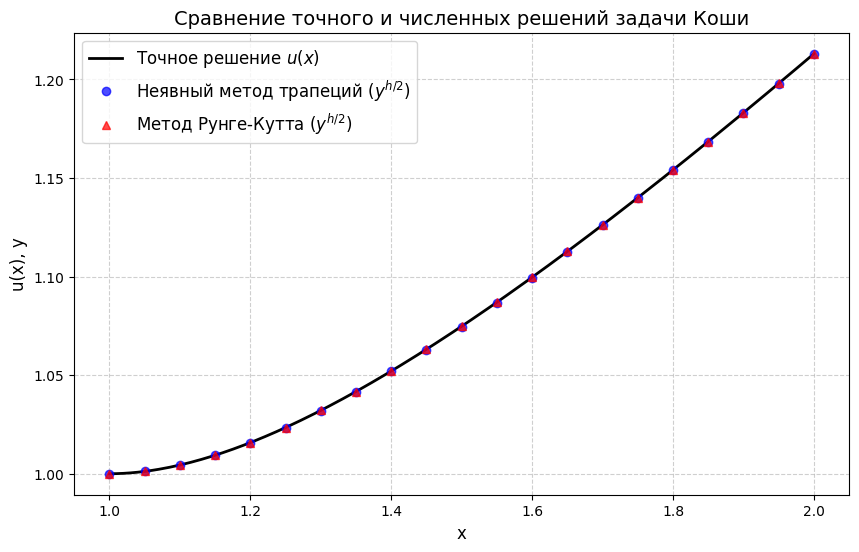

In [8]:
plt.figure(figsize=(10, 6))

# График точного решения
x_dense = np.linspace(a, b, 200)
plt.plot(x_dense, exact_solution(x_dense), 'k-', linewidth=2, label='Точное решение $u(x)$')

# Точечные графики численных решений (сетка h/2)
plt.plot(x_trap_h2, y_trap_h2, 'bo', markersize=6, alpha=0.7, label='Неявный метод трапеций ($y^{h/2}$)')
plt.plot(x_rk_h2, y_rk_h2, 'r^', markersize=6, alpha=0.7, label='Метод Рунге-Кутта ($y^{h/2}$)')

plt.title('Сравнение точного и численных решений задачи Коши', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('u(x), y', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.show()

### 6. Выводы

В ходе выполнения лабораторной работы я реализовал численное решение задачи Коши двумя методами: неявным методом трапеций и явным методом Рунге-Кутта 3-го порядка.

1. **Реализация методов:** Неявный метод трапеций потребовал построения итерационного процесса Ньютона, который успешно сходился за несколько итераций благодаря хорошему начальному приближению (явный шаг Эйлера) и гладкости функции. Явный метод Рунге-Кутта был запрограммирован строго по формулам, вытекающим из заданной таблицы Бутчера.
2. **Точность:** Метод Рунге-Кутта ($p=3$) ожидаемо продемонстрировал более высокую точность, чем метод трапеций ($p=2$). Разница составила несколько порядков, что логично вытекает из алгебраической степени точности рассматриваемых квадратурных формул.
3. **Оценка Рунге:** Апостериорная оценка погрешности по правилу Рунге дала значения, очень близкие к фактической максимальной погрешности численного решения. Это доказывает, что правило Рунге является надежным практическим инструментом для оценки точности и может использоваться для автоматического контроля шага сетки.
4. **Графический анализ:** На построенном графике точечные значения обоих методов визуально полностью ложатся на непрерывную кривую точного решения. Это свидетельствует об устойчивости и корректности программной реализации алгоритмов.